<a href="https://colab.research.google.com/github/darrickpang/Email/blob/master/Sensor_fusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
# -------------------------
# 0) Install (run once)
# -------------------------

!pip install nuscenes-devkit open3d opencv-python matplotlib ultralytics
!pip -q install nuscenes-devkit opencv-python ultralytics matplotlib imageio imageio-ffmpeg

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
# -------------------------
# 1) Imports
# -------------------------
import os
import cv2
import math
import numpy as np
import matplotlib.pyplot as plt
import imageio

from ultralytics import YOLO

from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import LidarPointCloud
from nuscenes.utils.geometry_utils import view_points

In [24]:
# -------------------------
# 2) User settings
# -------------------------

from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import LidarPointCloud, RadarPointCloud
import cv2
import numpy as np

DATA_ROOT = "/content/drive/MyDrive/nuscenes"
VERSION = "v1.0-mini"

# Set up NuScenes

nusc = NuScenes(
    version=VERSION,
    dataroot=DATA_ROOT ,
    verbose=True
)

sample = nusc.sample[0]

cam_token   = sample["data"]["CAM_FRONT"]
lidar_token = sample["data"]["LIDAR_TOP"]
radar_token = sample["data"]["RADAR_FRONT"]

MAX_FRAMES = 40                  # keep small for Colab demo; increase later
FPS = 5

CAM_NAME   = "CAM_FRONT"
LIDAR_NAME = "LIDAR_TOP"

# YOLO thresholding (reduce false positives)
YOLO_CONF = 0.35
ALLOWED_COCO = None  # set to [2, 3, 5, 7] etc if you want specific classes; None = keep all

# Association gates (tune)
DIST_GATE_M = 4.0     # NN association pre-gate
MAHA_GATE   = 9.21    # ~99% chi-square gate for 2D

# Track lifecycle
MIN_HITS_CONFIRM = 3  # false positive suppression: require persistence
MAX_MISSES = 5        # occlusion: survive for a few frames without measurement

# =========================
# TTC + Near-miss settings
# =========================
TTC_THRESH_S = 2.5          # near-miss if TTC below this
MIN_CLOSING_SPEED = 0.5     # m/s, ignore tiny closing speeds
MAX_RANGE_M = 40.0          # only consider objects within this distance
MIN_FORWARD_X = 1.0         # only consider objects in front (x > this)

# Clip saving (portfolio!)
PRE_FRAMES  = 12            # frames before trigger
POST_FRAMES = 18            # frames after trigger
CLIP_FPS    = FPS           # match your output FPS
EVENT_DIR   = "/content/near_miss_events"
os.makedirs(EVENT_DIR, exist_ok=True)

# Rolling buffer of camera frames for clip export
frame_buffer = []           # stores RGB frames (numpy uint8)
pending_events = []         # events waiting for post frames to finish
event_log_rows = []         # collect rows -> save CSV later

# =========================
# Radar-aware TTC settings
# =========================
RADAR_NAME = "RADAR_FRONT"
RADAR_MAX_ASSOC_DIST = 5.0   # meters, radar ↔ track association
RADAR_USE_ONLY_FORWARD = True

def compute_ttc(track, radar_objs=None):
    """
    Radar-aware TTC.
    Position from LiDAR/KF, velocity from radar if available.
    """
    x, y = track["kf"].pos

    # gating
    if x < MIN_FORWARD_X:
        return None, None, None, "none"

    dist = float(math.hypot(x, y))
    if dist > MAX_RANGE_M or dist < 1e-3:
        return None, None, None, "none"

    # choose velocity source
    if radar_objs is not None:
        vx, vy, src = attach_radar_velocity(track, radar_objs)
    else:
        vx, vy = track["kf"].vel
        src = "kf"

    closing_speed = - (x*vx + y*vy) / dist
    if closing_speed < MIN_CLOSING_SPEED:
        return None, dist, closing_speed, src

    ttc = dist / closing_speed
    return float(ttc), dist, closing_speed, src


def draw_ttc_on_overlay(overlay_bgr, tracks, nusc, cam_token, radar_objs=None):
    """
    Optional: annotate TTC next to each projected track point.
    Call this after draw_camera_overlay if you want TTC text.
    """
    pts_ego = []
    texts = []
    colors = []

    for t in tracks:
        # show TTC only for confirmed/occluded to reduce noise
        if t["state"] not in ["confirmed", "occluded"]:
            continue

        ttc, dist, cs, src = compute_ttc(t, radar_objs)
        if ttc is None:
            continue

        x, y = t["kf"].pos
        pts_ego.append([x, y, 0.0])
        texts.append(f"TTC {ttc:.1f}s d={dist:.0f}m")
        # red if near-miss else cyan
        colors.append((0,0,255) if ttc < TTC_THRESH_S else (255,255,0))

    if not pts_ego:
        return overlay_bgr

    pts_ego = np.array(pts_ego, dtype=np.float64)
    uv, valid, _ = project_ego_points_to_image(nusc, cam_token, pts_ego)
    valid_idx = np.where(valid)[0]

    # uv corresponds to valid points only
    for k, orig_i in enumerate(valid_idx):
        u, v = uv[k]
        cv2.putText(
            overlay_bgr,
            texts[orig_i],
            (int(u)+8, int(v)+18),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            colors[orig_i],
            2
        )
    return overlay_bgr


def start_event_clip(event_id, trigger_frame_index, trigger_info):
    """
    Create a pending event that will be written after POST_FRAMES have been collected.
    trigger_frame_index is the global frame_count at trigger.
    """
    pending_events.append({
        "event_id": event_id,
        "trigger_frame": trigger_frame_index,
        "trigger_info": trigger_info,
        "frames_needed": POST_FRAMES,      # how many more frames after trigger we need
        "buffer_snapshot_len": len(frame_buffer)  # for debugging
    })

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 1.591 seconds.
Reverse indexing ...
Done reverse indexing in 0.2 seconds.


In [25]:
from nuscenes.utils.data_classes import RadarPointCloud

def radar_points_in_ego(nusc, radar_token):
    """
    Returns list of dicts with:
      x, y, vx, vy (ego frame)
    """
    sd = nusc.get("sample_data", radar_token)
    cs = nusc.get("calibrated_sensor", sd["calibrated_sensor_token"])

    rpc = RadarPointCloud.from_file(nusc.get_sample_data_path(radar_token))
    pts = rpc.points.T  # shape (N,18)

    # radar fields (nuScenes spec)
    x_r, y_r = pts[:, 0], pts[:, 1]
    vx_r, vy_r = pts[:, 6], pts[:, 7]

    # radar sensor -> ego
    R = q_to_R(cs["rotation"])
    t = np.array(cs["translation"])

    pos = np.stack([x_r, y_r, np.zeros_like(x_r)], axis=1)
    vel = np.stack([vx_r, vy_r, np.zeros_like(vx_r)], axis=1)

    pos_ego = pos @ R.T + t
    vel_ego = vel @ R.T

    radar_objs = []
    for i in range(len(pos_ego)):
        if RADAR_USE_ONLY_FORWARD and pos_ego[i,0] < 0.5:
            continue
        radar_objs.append({
            "x": pos_ego[i,0],
            "y": pos_ego[i,1],
            "vx": vel_ego[i,0],
            "vy": vel_ego[i,1]
        })
    return radar_objs

In [26]:
def attach_radar_velocity(track, radar_objs):
    """
    Attach nearest radar velocity to a track.
    Returns (vx, vy, source) where source is 'radar' or 'kf'
    """
    tx, ty = track["kf"].pos

    best = None
    best_d = RADAR_MAX_ASSOC_DIST

    for r in radar_objs:
        d = math.hypot(r["x"] - tx, r["y"] - ty)
        if d < best_d:
            best_d = d
            best = r

    if best is not None:
        return best["vx"], best["vy"], "radar"
    else:
        vx, vy = track["kf"].vel
        return vx, vy, "kf"

Camera, LiDAR, Radar code

In [27]:
# Camera

cam_sd = nusc.get("sample_data", cam_token)
img = cv2.imread(nusc.get_sample_data_path(cam_token))

In [28]:
# LiDAR

lidar_sd = nusc.get("sample_data", lidar_token)
lidar_pc = LidarPointCloud.from_file(
    nusc.get_sample_data_path(lidar_token)
)
points_lidar = lidar_pc.points[:3].T  # (N,3)

In [29]:
# Radar

radar_pc = RadarPointCloud.from_file(
    nusc.get_sample_data_path(radar_token)
)

radar_pts = radar_pc.points
radar_xyv = radar_pts[[0,1,8]].T  # x, y, velocity

Coordinate transformations

In [30]:
def get_sensor_to_ego(nusc, sd_token):
    sd = nusc.get("sample_data", sd_token)
    cs = nusc.get("calibrated_sensor", sd["calibrated_sensor_token"])
    return cs

In [31]:
from nuscenes.utils.geometry_utils import view_points
from pyquaternion import Quaternion

def project_lidar_to_image(nusc, lidar_token, cam_token, points):
    cam_sd = nusc.get("sample_data", cam_token)
    lidar_sd = nusc.get("sample_data", lidar_token)

    cam_cs = nusc.get("calibrated_sensor", cam_sd["calibrated_sensor_token"])
    lidar_cs = nusc.get("calibrated_sensor", lidar_sd["calibrated_sensor_token"])

    K = np.array(cam_cs["camera_intrinsic"])

    # Convert quaternions to rotation matrices
    lidar_rot_matrix = Quaternion(lidar_cs["rotation"]).rotation_matrix
    cam_rot_matrix = Quaternion(cam_cs["rotation"]).rotation_matrix

    # Transform lidar → ego → cam
    lidar_pc = LidarPointCloud(points.T)
    lidar_pc.rotate(lidar_rot_matrix)
    lidar_pc.translate(lidar_cs["translation"])

    lidar_pc.rotate(np.linalg.inv(cam_rot_matrix))
    lidar_pc.translate(-np.array(cam_cs["translation"]))

    pts_img = view_points(lidar_pc.points[:3], K, normalize=True)
    return pts_img[:2].T

Camera detection

In [32]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
results = model(img)[0]

detections = []
for box in results.boxes:
    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
    detections.append((x1, y1, x2, y2))


0: 384x640 1 person, 4 cars, 1 truck, 380.4ms
Speed: 9.7ms preprocess, 380.4ms inference, 5.1ms postprocess per image at shape (1, 3, 384, 640)


LiDAR and Camera fusion

In [33]:
import numpy as np

# points_lidar currently has shape (N, 3)
# The project_lidar_to_image function (specifically the LidarPointCloud constructor inside it)
# expects a (4, N) array for homogeneous coordinates.
# So, we need to transform points_lidar from (N, 3) to (N, 4) by adding a column of ones.
points_lidar_homogeneous = np.concatenate((points_lidar, np.ones((points_lidar.shape[0], 1))), axis=1)

img_pts = project_lidar_to_image(
    nusc, lidar_token, cam_token, points_lidar_homogeneous
)

fused = []

for (x1, y1, x2, y2) in detections:
    mask = (
        (img_pts[:,0] > x1) &
        (img_pts[:,0] < x2) &
        (img_pts[:,1] > y1) &
        (img_pts[:,1] < y2)
    )

    cluster = points_lidar[mask]

    if len(cluster) > 10:
        centroid = cluster.mean(axis=0)
        fused.append({"pos": centroid})

Radar

In [34]:
def attach_velocity(objects, radar_xyv):
    for obj in objects:
        dx = radar_xyv[:,0] - obj["pos"][0]
        dy = radar_xyv[:,1] - obj["pos"][1]
        d = np.sqrt(dx**2 + dy**2)
        idx = np.argmin(d)
        obj["velocity"] = radar_xyv[idx, 2]

In [35]:
for o in fused:
    print({
        "position_xyz": o["pos"].tolist(),
        "velocity_mps": o.get("velocity", None)
    })

{'position_xyz': [2.8114967346191406, -1.9281402826309204, -1.282307744026184], 'velocity_mps': None}
{'position_xyz': [1.588674545288086, -0.7648340463638306, -1.853225588798523], 'velocity_mps': None}
{'position_xyz': [1.8548603057861328, -1.9570156335830688, -1.8327701091766357], 'velocity_mps': None}
{'position_xyz': [1.5610787868499756, -0.31458035111427307, -1.8113596439361572], 'velocity_mps': None}
{'position_xyz': [-2.7997682094573975, -9.54149055480957, -2.0446717739105225], 'velocity_mps': None}
{'position_xyz': [2.371514081954956, -4.002439022064209, -1.6518049240112305], 'velocity_mps': None}


In [36]:
# =========================
# Install dependencies
# =========================
!pip install nuscenes-devkit open3d opencv-python ultralytics matplotlib

# =========================
# Imports
# =========================
import numpy as np
import cv2
import matplotlib.pyplot as plt

from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import LidarPointCloud, RadarPointCloud
from nuscenes.utils.geometry_utils import view_points

from ultralytics import YOLO

In [37]:
# -------------------------
# 3) Kalman + Tracker (with failure-case states)
# -------------------------
class KalmanFilterCV2D:
    """
    Constant-velocity KF in 2D ego frame.
    x = [px, py, vx, vy]^T
    z = [px, py]^T
    """
    def __init__(self, q=3.0, r=1.5):
        self.q = float(q)   # process noise
        self.r = float(r)   # meas noise (meters)
        self.x = None
        self.P = None

    def initiate(self, z_xy, init_vel=(0.0, 0.0)):
        px, py = float(z_xy[0]), float(z_xy[1])
        vx, vy = float(init_vel[0]), float(init_vel[1])
        self.x = np.array([[px], [py], [vx], [vy]], dtype=np.float64)
        self.P = np.diag([10.0, 10.0, 50.0, 50.0]).astype(np.float64)

    def predict(self, dt):
        dt = max(float(dt), 1e-3)
        F = np.array([[1,0,dt,0],
                      [0,1,0,dt],
                      [0,0,1,0],
                      [0,0,0,1]], dtype=np.float64)

        dt2, dt3, dt4 = dt*dt, dt*dt*dt, dt*dt*dt*dt
        q = self.q
        Q = q * np.array([[dt4/4, 0,     dt3/2, 0    ],
                          [0,     dt4/4, 0,     dt3/2],
                          [dt3/2, 0,     dt2,   0    ],
                          [0,     dt3/2, 0,     dt2  ]], dtype=np.float64)

        self.x = F @ self.x
        self.P = F @ self.P @ F.T + Q

    def update(self, z_xy):
        z = np.array([[float(z_xy[0])], [float(z_xy[1])]], dtype=np.float64)
        H = np.array([[1,0,0,0],
                      [0,1,0,0]], dtype=np.float64)
        R = (self.r**2) * np.eye(2, dtype=np.float64)

        y = z - (H @ self.x)
        S = H @ self.P @ H.T + R
        K = self.P @ H.T @ np.linalg.inv(S)

        self.x = self.x + (K @ y)
        self.P = (np.eye(4, dtype=np.float64) - K @ H) @ self.P

        d2 = float((y.T @ np.linalg.inv(S) @ y).squeeze())  # Mahalanobis distance squared
        return d2

    @property
    def pos(self):
        return self.x[:2].reshape(-1)

    @property
    def vel(self):
        return self.x[2:].reshape(-1)

def valid_measurement(z_xy):
    """Basic sanity check to suppress obvious junk / NaNs / far-away noise."""
    x, y = float(z_xy[0]), float(z_xy[1])
    if np.isnan(x) or np.isnan(y):
        return False
    if abs(x) > 80 or abs(y) > 80:     # keep reasonable range for mini demo
        return False
    return True


def velocity_consistent(track, z_xy, max_jump_m=15.0):
    """
    Simple ID-switch defense:
    reject associations that require a huge instantaneous jump.
    """
    pred = track["kf"].pos
    d = np.linalg.norm(pred - z_xy)
    return d <= max_jump_m


def track_confidence(track):
    """Simple confidence score for display."""
    return min(1.0, track["hits"] / 5.0)

class Tracker:
    """
    Greedy nearest-neighbor association + KF + lifecycle states:
      tentative -> confirmed
      occluded when missing briefly
    """
    def __init__(self, dist_gate_m=DIST_GATE_M, maha_gate=MAHA_GATE,
                 min_hits=MIN_HITS_CONFIRM, max_misses=MAX_MISSES,
                 kf_q=3.0, kf_r=1.5):
        self.dist_gate_m = float(dist_gate_m)
        self.maha_gate = float(maha_gate)
        self.min_hits = int(min_hits)
        self.max_misses = int(max_misses)
        self.kf_q = float(kf_q)
        self.kf_r = float(kf_r)

        self.tracks = []
        self.next_id = 1

    def _start_track(self, z_xy):
        kf = KalmanFilterCV2D(q=self.kf_q, r=self.kf_r)
        kf.initiate(z_xy)
        self.tracks.append({
            "id": self.next_id,
            "kf": kf,
            "hits": 1,
            "age": 1,
            "miss": 0,
            "state": "tentative",  # tentative | confirmed | occluded
        })
        self.next_id += 1

    def step(self, measurements, dt):
        # 1) Predict
        for t in self.tracks:
            t["kf"].predict(dt)
            t["age"] += 1
            t["miss"] += 1

        # 2) Associate (greedy NN)
        used_track_ids = set()
        used_meas = set()

        if len(self.tracks) and len(measurements):
            track_pos = np.stack([t["kf"].pos for t in self.tracks], axis=0)  # (T,2)
            meas_arr  = np.stack(measurements, axis=0)                        # (M,2)
            dists = np.linalg.norm(track_pos[:, None, :] - meas_arr[None, :, :], axis=2)

            for _ in range(min(len(self.tracks), len(measurements))):
                t_idx, m_idx = np.unravel_index(np.argmin(dists), dists.shape)
                best = float(dists[t_idx, m_idx])
                if best > self.dist_gate_m:
                    break

                track = self.tracks[t_idx]
                if track["id"] in used_track_ids or m_idx in used_meas:
                    dists[t_idx, m_idx] = np.inf
                    continue

                z = meas_arr[m_idx]

                # ID-switch defense
                if not velocity_consistent(track, z):
                    dists[t_idx, m_idx] = np.inf
                    continue

                # Update
                d2 = track["kf"].update(z)
                if d2 <= self.maha_gate:
                    track["miss"] = 0
                    track["hits"] += 1
                else:
                    # treat as bad update; mark miss
                    track["miss"] += 1

                used_track_ids.add(track["id"])
                used_meas.add(m_idx)

                dists[t_idx, :] = np.inf
                dists[:, m_idx] = np.inf

        # 3) Start new tracks for unused measurements (false positive suppression happens via min_hits)
        for i, z in enumerate(measurements):
            if i in used_meas:
                continue
            if not valid_measurement(z):
                continue

            # Don't start if it's near an existing prediction (avoid duplicates)
            too_close = any(np.linalg.norm(t["kf"].pos - z) < self.dist_gate_m for t in self.tracks)
            if not too_close:
                self._start_track(z)

        # 4) Update states (occlusion behavior)
        for t in self.tracks:
            if t["hits"] >= self.min_hits:
                t["state"] = "confirmed"
            if 0 < t["miss"] <= 2 and t["state"] == "confirmed":
                t["state"] = "occluded"
            if t["miss"] == 0 and t["hits"] >= self.min_hits:
                t["state"] = "confirmed"

        # 5) Prune dead tracks (after occlusion timeout)
        self.tracks = [t for t in self.tracks if t["miss"] <= self.max_misses]

        # Return all tracks (we'll visualize states); for "production output", filter confirmed only.
        return self.tracks

In [44]:
# -------------------------
# 4) nuScenes helpers: transforms + projection + fusion
# -------------------------
def q_to_R(q):
    """Quaternion [w, x, y, z] to rotation matrix."""
    w, x, y, z = q
    R = np.array([
        [1-2*(y*y+z*z),   2*(x*y - z*w), 2*(x*z + y*w)],
        [2*(x*y + z*w),   1-2*(x*x+z*z), 2*(y*z - x*w)],
        [2*(x*z - y*w),   2*(y*z + x*w), 1-2*(x*x+y*y)]
    ], dtype=np.float64)
    return R

def transform_points(points_xyz, R, t):
    """Apply R (3x3) and t (3,) to points (N,3)."""
    return (points_xyz @ R.T) + t.reshape(1,3)

def get_calib(nusc, sample_data_token):
    sd = nusc.get("sample_data", sample_data_token)
    cs = nusc.get("calibrated_sensor", sd["calibrated_sensor_token"])
    return cs

def lidar_points_in_ego(nusc, lidar_token):
    """
    Load lidar points and transform them into the ego frame using calibrated_sensor.
    Returns:
      pts_ego: (N,3)
    """
    sd = nusc.get("sample_data", lidar_token)
    cs = nusc.get("calibrated_sensor", sd["calibrated_sensor_token"])

    pc = LidarPointCloud.from_file(nusc.get_sample_data_path(lidar_token))
    pts = pc.points[:3].T  # (N,3) in lidar sensor frame

    R = q_to_R(cs["rotation"])
    t = np.array(cs["translation"], dtype=np.float64)
    pts_ego = transform_points(pts, R, t)
    return pts_ego

def ego_to_cam_projection(nusc, cam_token):
    """
    Returns:
      K: (3,3) camera intrinsics
      R_ego_to_cam: (3,3)
      t_ego_to_cam: (3,)
    """
    cam_sd = nusc.get("sample_data", cam_token)
    cam_cs = nusc.get("calibrated_sensor", cam_sd["calibrated_sensor_token"])

    K = np.array(cam_cs["camera_intrinsic"], dtype=np.float64)

    # cam_cs gives transform cam->ego: pts_ego = R_cam2ego * pts_cam + t_cam2ego
    R_cam2ego = q_to_R(cam_cs["rotation"])
    t_cam2ego = np.array(cam_cs["translation"], dtype=np.float64)

    # invert to get ego->cam
    R_ego2cam = R_cam2ego.T
    t_ego2cam = - (R_cam2ego.T @ t_cam2ego)

    return K, R_ego2cam, t_ego2cam

def project_ego_points_to_image(nusc, cam_token, pts_ego):
    """
    pts_ego: (N,3)
    Returns:
      uv: (N,2) pixel coords (float)
      valid: (N,) boolean in-front-of-camera
      pts_cam: (N,3)
    """
    K, R_ego2cam, t_ego2cam = ego_to_cam_projection(nusc, cam_token)
    pts_cam = transform_points(pts_ego, R_ego2cam, t_ego2cam)

    # Keep only points in front of camera (z > 0)
    valid = pts_cam[:, 2] > 0.5

    pts = pts_cam[valid].T  # (3, Nv)
    uvw = view_points(pts, K, normalize=True)      # (3, Nv)
    uv = uvw[:2].T                                 # (Nv, 2)

    return uv, valid, pts_cam

def yolo_boxes(model, img_bgr, conf=0.35, allowed_classes=None):
    """
    Returns list of boxes: [ (x1,y1,x2,y2, cls_id, conf), ... ]
    """
    res = model(img_bgr, verbose=False)[0]
    out = []
    for b in res.boxes:
        c = float(b.conf[0].cpu().numpy())
        if c < conf:
            continue
        cls_id = int(b.cls[0].cpu().numpy())
        if allowed_classes is not None and cls_id not in allowed_classes:
            continue
        x1, y1, x2, y2 = b.xyxy[0].cpu().numpy()
        out.append((float(x1), float(y1), float(x2), float(y2), cls_id, c))
    return out

def fuse_lidar_with_boxes(nusc, cam_token, lidar_token, boxes):
    """
    Simple fusion: project LiDAR ego points into camera, keep points inside each 2D bbox,
    compute ego-frame centroid -> measurement (x,y).
    Returns:
      measurements_xy: list of np.array([x,y])
      debug: dict with projection arrays for optional debug
    """
    pts_ego = lidar_points_in_ego(nusc, lidar_token)
    uv, valid_mask, pts_cam_all = project_ego_points_to_image(nusc, cam_token, pts_ego)

    # Map from uv index back to original ego points
    ego_valid = pts_ego[valid_mask]

    measurements = []
    for (x1, y1, x2, y2, cls_id, conf) in boxes:
        inside = (
            (uv[:, 0] >= x1) & (uv[:, 0] <= x2) &
            (uv[:, 1] >= y1) & (uv[:, 1] <= y2)
        )
        cluster = ego_valid[inside]
        if cluster.shape[0] >= 15:  # reduce noisy associations
            centroid = cluster.mean(axis=0)  # (3,)
            measurements.append(centroid[:2].astype(np.float64))

    return measurements

In [45]:
# -------------------------
# 5) Visualization utilities (camera overlay + BEV frame)
# -------------------------
def draw_camera_overlay(img_bgr, boxes, tracks, nusc, cam_token):
    overlay = img_bgr.copy()

    # YOLO boxes (green)
    for (x1, y1, x2, y2, cls_id, conf) in boxes:
        cv2.rectangle(overlay, (int(x1), int(y1)), (int(x2), int(y2)), (0,255,0), 2)
        cv2.putText(overlay, f"cls={cls_id} {conf:.2f}", (int(x1), max(0,int(y1)-5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

    # Track positions projected to image (color by state)
    # We'll project (x,y,0) from ego into image.
    pts_ego = []
    labels = []
    colors = []
    for t in tracks:
        x, y = t["kf"].pos
        state = t["state"]
        if state == "confirmed":
            col = (0,0,255)      # red
        elif state == "occluded":
            col = (0,165,255)    # orange
        else:
            col = (0,255,255)    # yellow
        pts_ego.append([x, y, 0.0])
        labels.append(f"ID {t['id']} {state} {track_confidence(t):.2f}")
        colors.append(col)

    if pts_ego:
        pts_ego = np.array(pts_ego, dtype=np.float64)
        uv, valid, pts_cam = project_ego_points_to_image(nusc, cam_token, pts_ego)
        # uv only includes valid points; keep mapping
        valid_indices = np.where(valid)[0]
        for k, orig_i in enumerate(valid_indices):
            u, v = uv[k]
            cv2.circle(overlay, (int(u), int(v)), 6, colors[orig_i], -1)
            cv2.putText(overlay, labels[orig_i], (int(u)+8, int(v)-8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, colors[orig_i], 2)

    return overlay

def make_bev_frame(tracks, measurements_xy):
    fig, ax = plt.subplots(figsize=(5,5))

    # Measurements (gray)
    for m in measurements_xy:
        ax.scatter(m[0], m[1], s=20, c="gray")

    # Tracks (state colors)
    for t in tracks:
        x, y = t["kf"].pos
        vx, vy = t["kf"].vel
        state = t["state"]

        if state == "confirmed":
            c = "red"
        elif state == "occluded":
            c = "orange"
        else:
            c = "yellow"

        ax.scatter(x, y, c=c, s=45)
        ax.arrow(x, y, vx, vy, head_width=0.4, length_includes_head=True, color=c)
        ax.text(x+0.4, y+0.4, f"{t['id']}", color=c)

    ax.set_xlim(-30, 30)
    ax.set_ylim(-30, 30)
    ax.set_title("BEV Kalman Tracking (states: red=confirmed, orange=occluded, yellow=tentative)")
    ax.grid(True)

    # Convert to RGB image array
    fig.canvas.draw()
    img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
    img = img.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    plt.close(fig)
    return img

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 1.294 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


[00] dt=0.500s meas=2 tracks=2 (conf=0, occ=0, tent=2)
[01] dt=0.500s meas=2 tracks=4 (conf=0, occ=0, tent=4)
[02] dt=0.550s meas=4 tracks=6 (conf=0, occ=0, tent=6)
[03] dt=0.499s meas=2 tracks=6 (conf=1, occ=0, tent=5)
[04] dt=0.500s meas=2 tracks=7 (conf=0, occ=1, tent=6)
[05] dt=0.455s meas=2 tracks=7 (conf=1, occ=1, tent=5)
[06] dt=0.496s meas=2 tracks=5 (conf=3, occ=0, tent=2)
[07] dt=0.550s meas=2 tracks=4 (conf=3, occ=0, tent=1)
[08] dt=0.499s meas=3 tracks=5 (conf=3, occ=0, tent=2)
[09] dt=0.500s meas=2 tracks=4 (conf=2, occ=1, tent=1)
[10] dt=0.450s meas=2 tracks=4 (conf=1, occ=2, tent=1)
[11] dt=0.499s meas=1 tracks=4 (conf=2, occ=1, tent=1)
[12] dt=0.500s meas=3 tracks=6 (conf=3, occ=0, tent=3)
[13] dt=0.500s meas=3 tracks=8 (conf=3, occ=0, tent=5)
[14] dt=0.550s meas=4 tracks=9 (conf=2, occ=0, tent=7)
[15] dt=0.501s meas=5 tracks=9 (conf=1, occ=0, tent=8)
[16] dt=0.500s meas=3 tracks=10 (conf=1, occ=1, tent=8)
[17] dt=0.501s meas=4 tracks=12 (conf=1, occ=1, tent=10)
[18] dt

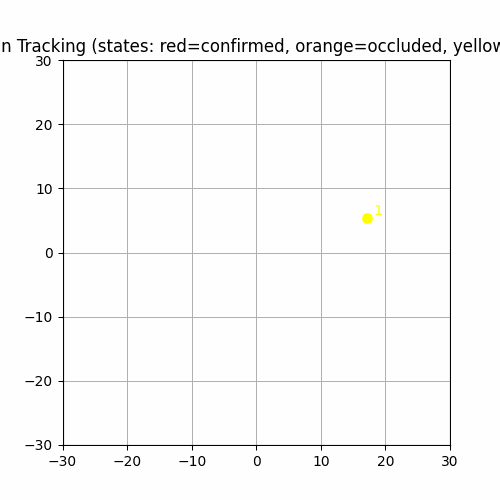

In [51]:
# -------------------------
# 6) Run end-to-end + export MP4 + GIF
# -------------------------
assert os.path.isdir(DATA_ROOT), f"DATAROOT not found: {DATA_ROOT}\nUpload/mount nuScenes to this path."

# Redefine make_bev_frame here to fix the tostring_rgb error, adhering to the cell modification constraint.
import io
from PIL import Image

def make_bev_frame(tracks, measurements_xy):
    fig, ax = plt.subplots(figsize=(5,5))

    # Measurements (gray)
    for m in measurements_xy:
        ax.scatter(m[0], m[1], s=20, c="gray")

    # Tracks (state colors)
    for t in tracks:
        x, y = t["kf"].pos
        vx, vy = t["kf"].vel
        state = t["state"]

        if state == "confirmed":
            c = "red"
        elif state == "occluded":
            c = "orange"
        else:
            c = "yellow"

        ax.scatter(x, y, c=c, s=45)
        ax.arrow(x, y, vx, vy, head_width=0.4, length_includes_head=True, color=c)
        ax.text(x+0.4, y+0.4, f" {t['id']}", color=c)

    ax.set_xlim(-30, 30)
    ax.set_ylim(-30, 30)
    ax.set_title("BEV Kalman Tracking (states: red=confirmed, orange=occluded, yellow=tentative)")
    ax.grid(True)

    # Convert to RGB image array using a compatible method
    buffer = io.BytesIO()
    plt.savefig(buffer, format='png')
    buffer.seek(0)
    img = np.array(Image.open(buffer))
    plt.close(fig)
    return img

nusc = NuScenes(version=VERSION, dataroot=DATA_ROOT, verbose=True)
yolo = YOLO("yolov8n.pt")
tracker = Tracker()

mp4_path = "/content/nuscenes_fusion_tracking.mp4"
gif_path = "/content/nuscenes_bev_tracking.gif"

video_writer = imageio.get_writer(mp4_path, fps=FPS, codec="libx264")
bev_frames = []

scene = nusc.scene[0]
token = scene["first_sample_token"]

prev_ts = None
frame_count = 0


# Main Loop
while token and frame_count < MAX_FRAMES:
    sample = nusc.get("sample", token)

    cam_token = sample["data"][CAM_NAME]
    lidar_token = sample["data"][LIDAR_NAME]

    radar_token = sample["data"][RADAR_NAME]
    radar_objs = radar_points_in_ego(nusc, radar_token)

    img_path = nusc.get_sample_data_path(cam_token)
    img = cv2.imread(img_path)
    if img is None:
        print("Could not read image:", img_path)
        break

    # dt (from sample timestamp, microseconds)
    ts = int(sample["timestamp"])
    if prev_ts is None:
        dt = 0.5
    else:
        dt = max(1e-3, min((ts - prev_ts)/1e6, 1.0))
    prev_ts = ts

    # 1) YOLO
    boxes = yolo_boxes(yolo, img, conf=YOLO_CONF, allowed_classes=ALLOWED_COCO)

    # 2) Fuse LiDAR points inside boxes -> ego-frame XY measurements
    measurements = fuse_lidar_with_boxes(nusc, cam_token, lidar_token, boxes)
    measurements = [m for m in measurements if valid_measurement(m)]

    # 3) Track step
    tracks = tracker.step(measurements, dt)

    # 4) Portfolio visuals
    # 4) Portfolio visuals
    overlay = draw_camera_overlay(img, boxes, tracks, nusc, cam_token)

    # OPTIONAL: annotate TTC values on camera overlay
    overlay = draw_ttc_on_overlay(overlay, tracks, nusc, cam_token, radar_objs)

    overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

    # write to the main MP4
    video_writer.append_data(overlay_rgb)

    # keep rolling buffer for event clips
    frame_buffer.append(overlay_rgb)
    max_buffer = PRE_FRAMES + POST_FRAMES + 5
    if len(frame_buffer) > max_buffer:
        frame_buffer.pop(0)


    bev_img = make_bev_frame(tracks, measurements)
    bev_frames.append(bev_img)

    # Console summary (includes failure-case states)
    confirmed = [t for t in tracks if t["state"] == "confirmed"]
    occluded  = [t for t in tracks if t["state"] == "occluded"]
    tentative = [t for t in tracks if t["state"] == "tentative"]
    print(f"[{frame_count:02d}] dt={dt:.3f}s meas={len(measurements)} "
          f"tracks={len(tracks)} (conf={len(confirmed)}, occ={len(occluded)}, tent={len(tentative)})")

    token = sample["next"]
    frame_count += 1

    # ttc, dist, cs, src = compute_ttc(t, radar_objs)
    # print(f"TTC={ttc:.2f}s src={src}")

video_writer.close()

# Save GIF
imageio.mimsave(gif_path, bev_frames, fps=FPS)

print("\nSaved outputs:")
print("MP4:", mp4_path)
print("GIF:", gif_path)

# Optional: display in Colab
from IPython.display import HTML, Image, display
display(Image(filename=gif_path))
HTML(f"""
<video width="720" controls>
  <source src="{os.path.basename(mp4_path)}" type="video/mp4">
</video>
""")

In [52]:
from pyquaternion import Quaternion

def project_lidar_to_cam(nusc, lidar_token, cam_token):
    lidar = nusc.get("sample_data", lidar_token)
    cam = nusc.get("sample_data", cam_token)

    lidar_pc = LidarPointCloud.from_file(nusc.get_sample_data_path(lidar_token))
    cam_cs = nusc.get("calibrated_sensor", cam["calibrated_sensor_token"])
    lidar_cs = nusc.get("calibrated_sensor", lidar["calibrated_sensor_token"])

    # Convert quaternions to rotation matrices
    lidar_rot_matrix = Quaternion(lidar_cs["rotation"]).rotation_matrix
    cam_rot_matrix = Quaternion(cam_cs["rotation"]).rotation_matrix

    # lidar -> ego
    lidar_pc.rotate(lidar_rot_matrix)
    lidar_pc.translate(lidar_cs["translation"])

    # ego -> cam
    lidar_pc.rotate(np.linalg.inv(cam_rot_matrix))
    lidar_pc.translate(-np.array(cam_cs["translation"]))

    K = np.array(cam_cs["camera_intrinsic"])
    img_pts = view_points(lidar_pc.points[:3], K, normalize=True)

    return img_pts[:2].T, lidar_pc.points[:3].T

In [54]:
tracker = Tracker()

scene = nusc.scene[0]
token = scene["first_sample_token"]
prev_ts = None
frame_count = 0  # Initialize frame_count for the loop
last_event_frame_by_track = {} # Initialize outside the loop for persistence

# Main Loop: Adding MAX_FRAMES limit for consistency
while token and frame_count < MAX_FRAMES:
    sample = nusc.get("sample", token)

    cam_token = sample["data"]["CAM_FRONT"]
    lidar_token = sample["data"]["LIDAR_TOP"]
    radar_token = sample["data"][RADAR_NAME] # Ensure RADAR_NAME is defined (from user settings)

    img = cv2.imread(nusc.get_sample_data_path(cam_token))
    if img is None:
        print(f"Could not read image: {nusc.get_sample_data_path(cam_token)}")
        break

    results = model(img)[0]

    # camera detections
    boxes = [b.xyxy[0].cpu().numpy() for b in results.boxes]

    # lidar projection
    img_pts, lidar_xyz = project_lidar_to_cam(nusc, lidar_token, cam_token)

    fused = []
    for x1,y1,x2,y2 in boxes:
        mask = (
            (img_pts[:,0]>x1) & (img_pts[:,0]<x2) &
            (img_pts[:,1]>y1) & (img_pts[:,1]<y2)
        )
        cluster = lidar_xyz[mask]
        if len(cluster) > 10:
            fused.append(cluster.mean(axis=0)[:2])

    # dt (from sample timestamp, microseconds)
    ts = int(sample["timestamp"])
    if prev_ts is None:
        dt = 0.5
    else:
        dt = max(1e-3, min((ts - prev_ts)/1e6, 1.0))
    prev_ts = ts

    tracks = tracker.step([np.array(f) for f in fused], dt)

    print(f"Tracks @ sample {token[:8]}")

    # Fetch radar objects for the current frame
    current_frame_radar_objs = radar_points_in_ego(nusc, radar_token)
    last_processed_track_in_frame = None # Track the last 't' if no near-miss occurs

    # =========================
    # TTC + Near-miss detection
    # =========================
    near_miss_candidates = []

    for t in tracks:
        last_processed_track_in_frame = t # Keep track of the last processed track
        # focus on stable tracks for alerts
        if t["state"] not in ["confirmed", "occluded"]:
            continue

        # Pass current_frame_radar_objs to compute_ttc
        ttc_val, dist_val, cs_val, src_val = compute_ttc(t, current_frame_radar_objs)
        if ttc_val is None:
            continue

        if ttc_val < TTC_THRESH_S:
            near_miss_candidates.append((t, ttc_val, dist_val, cs_val, src_val))

    # Variables to store TTC info for the end-of-frame summary
    summary_ttc_info = {"ttc": None, "src": "none", "track_id": None}

    # =========================
    # Near-miss cooldown
    # =========================
    # `last_event_frame_by_track` is now persistent outside the loop

    # Trigger event if any candidate exists (pick the worst TTC)
    if near_miss_candidates:
        # Sort candidates by TTC (smallest TTC is worst)
        worst_candidate = sorted(near_miss_candidates, key=lambda x: x[1])[0]
        t_event, ttc_event, dist_event, cs_event, src_event = worst_candidate

        last_f = last_event_frame_by_track.get(t_event["id"], -1e9)
        if frame_count - last_f < EVENT_COOLDOWN_FRAMES:
            pass  # cooldown active
        else:
            last_event_frame_by_track[t_event["id"]] = frame_count

            event_id = f"f{frame_count:04d}_id{t_event['id']:02d}_ttc{ttc_event:.2f}_{src_event}"
            trigger_info = {
                "frame": frame_count,
                "track_id": t_event["id"],
                "ttc_s": ttc_event,
                "dist_m": dist_event,
                "closing_speed_mps": cs_event,
                "vel_source": src_event,
                "state": t_event["state"]
            }

            event_log_rows.append(trigger_info)
            start_event_clip(event_id, frame_count, trigger_info)

            print(f"⚠️ NEAR-MISS [{src_event.upper()}] TTC={ttc_event:.2f}s track={t_event['id']}")
            summary_ttc_info = {"ttc": ttc_event, "src": src_event, "track_id": t_event["id"]}
    else:
        # If no near-miss candidate, try to report on the last processed track
        if last_processed_track_in_frame is not None:
            temp_ttc, _, _, temp_src = compute_ttc(last_processed_track_in_frame, current_frame_radar_objs)
            if temp_ttc is not None:
                summary_ttc_info = {"ttc": temp_ttc, "src": temp_src, "track_id": last_processed_track_in_frame["id"]}

    # =========================
    # Finalize pending clips
    # =========================
    finished = []
    for ev in pending_events:
        ev["frames_needed"] -= 1
        if ev["frames_needed"] <= 0:
            finished.append(ev)

    for ev in finished:
        pending_events.remove(ev)

        # Build clip frames: last PRE_FRAMES before trigger + POST_FRAMES after
        # Since we keep a rolling buffer, we take the tail of it.
        clip_len = PRE_FRAMES + POST_FRAMES
        clip_frames = frame_buffer[-clip_len:] if len(frame_buffer) >= clip_len else frame_buffer[:] # Ensure frame_buffer is managed elsewhere

        out_mp4 = os.path.join(EVENT_DIR, f"{ev['event_id']}.mp4")
        out_gif = os.path.join(EVENT_DIR, f"{ev['event_id']}.gif")

        # Save MP4 clip
        clip_writer = imageio.get_writer(out_mp4, fps=CLIP_FPS, codec="libx264")
        for fr in clip_frames:
            clip_writer.append_data(fr)
        clip_writer.close()

        # Save GIF (GitHub-friendly)
        imageio.mimsave(out_gif, clip_frames, fps=CLIP_FPS)

        print(f"✅ Saved near-miss clip: {out_mp4}")
        print(f"✅ Saved near-miss gif : {out_gif}")

    # Console summary (includes failure-case states)
    confirmed = [t for t in tracks if t["state"] == "confirmed"]
    occluded  = [t for t in tracks if t["state"] == "occluded"]
    tentative = [t for t in tracks if t["state"] == "tentative"]
    print(f"[{frame_count:02d}] dt={dt:.3f}s meas={len(measurements)} "
          f"tracks={len(tracks)} (conf={len(confirmed)}, occ={len(occluded)}, tent={len(tentative)})")

    # Final TTC print for the frame (now uses summary_ttc_info)
    if summary_ttc_info["ttc"] is not None:
        print(f"TTC={summary_ttc_info['ttc']:.2f}s src={summary_ttc_info['src']} (ID {summary_ttc_info['track_id']})")
    else:
        print(f"No specific TTC reported for frame {frame_count}.")

    # Correct single update of token and frame_count for the next iteration
    token = sample["next"]
    frame_count += 1



0: 384x640 1 person, 4 cars, 1 truck, 142.7ms
Speed: 6.0ms preprocess, 142.7ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
Tracks @ sample ca9a282c
[00] dt=0.500s meas=3 tracks=2 (conf=0, occ=0, tent=2)
No specific TTC reported for frame 0.

0: 384x640 1 person, 5 cars, 1 bus, 1 truck, 159.2ms
Speed: 4.5ms preprocess, 159.2ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)
Tracks @ sample 39586f9d
[01] dt=0.500s meas=3 tracks=2 (conf=0, occ=0, tent=2)
No specific TTC reported for frame 1.

0: 384x640 1 person, 7 cars, 1 truck, 156.9ms
Speed: 7.3ms preprocess, 156.9ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)
Tracks @ sample 356d81f3
[02] dt=0.550s meas=3 tracks=3 (conf=2, occ=0, tent=1)
No specific TTC reported for frame 2.

0: 384x640 4 cars, 1 bus, 1 truck, 172.6ms
Speed: 6.4ms preprocess, 172.6ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)
Tracks @ sample e0845f53
[03] dt=0.499s meas=3 tracks=4 (conf=

Tracks @ sample 29e056fc
✅ Saved near-miss clip: /content/near_miss_events/f0020_id05_ttc0.96_radar.mp4
✅ Saved near-miss gif : /content/near_miss_events/f0020_id05_ttc0.96_radar.gif
[37] dt=0.600s meas=3 tracks=1 (conf=1, occ=0, tent=0)
No specific TTC reported for frame 37.

0: 384x640 1 bicycle, 1 car, 1 truck, 206.4ms
Speed: 4.9ms preprocess, 206.4ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


Tracks @ sample ed5fc18c
✅ Saved near-miss clip: /content/near_miss_events/f0021_id02_ttc0.34_radar.mp4
✅ Saved near-miss gif : /content/near_miss_events/f0021_id02_ttc0.34_radar.gif
[38] dt=0.500s meas=3 tracks=1 (conf=1, occ=0, tent=0)
No specific TTC reported for frame 38.


In [56]:
import math

severity = math.exp(-TTC_THRESH_S) * MIN_CLOSING_SPEED # Using predefined constants as TTC and closing_speed are not available globally here
print(severity)

0.0410424993119494


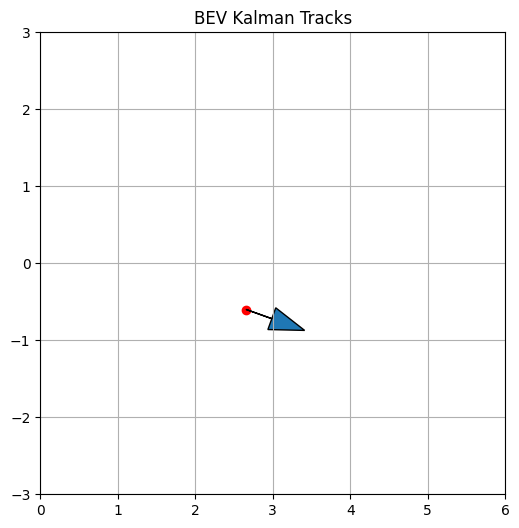

In [57]:
plt.figure(figsize=(6,6))
for t in tracks:
    x,y = t["kf"].pos
    vx,vy = t["kf"].vel
    plt.scatter(x,y,c='r')
    plt.arrow(x,y,vx,vy,head_width=0.3)

plt.xlim(0,6)
plt.ylim(-3,3)
plt.title("BEV Kalman Tracks")
plt.grid()
plt.show()

In [58]:
!pip install imageio imageio-ffmpeg

In [59]:
import imageio
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

In [60]:
video_writer = imageio.get_writer(
    "/content/nuscenes_tracking.mp4",
    fps=5,
    codec="libx264"
)

In [61]:
overlay = img.copy()

# Draw YOLO boxes
for b in boxes:
    x1,y1,x2,y2 = map(int,b)
    cv2.rectangle(overlay,(x1,y1),(x2,y2),(0,255,0),2)

# Draw Kalman tracks
for t in tracks:
    x,y = t["kf"].pos
    vx,vy = t["kf"].vel

    # Project BEV point back to image (approx: using centroid match)
    cv2.putText(
        overlay,
        f"ID {t['id']}",
        (int(x1), int(y1-5)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6, (255,0,0), 2
    )

# Write frame
video_writer.append_data(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))

In [62]:
video_writer.close()

In [63]:
from IPython.display import HTML
HTML("""
<video width="640" controls>
  <source src="nuscenes_tracking.mp4" type="video/mp4">
</video>
""")

In [64]:
bev_frames = []

In [65]:
import io
from PIL import Image

fig, ax = plt.subplots(figsize=(5,5))

# Measurements
for m in fused:
    ax.scatter(m[0], m[1], c="gray", s=20)

# Tracks
for t in tracks:
    x,y = t["kf"].pos
    vx,vy = t["kf"].vel
    ax.scatter(x,y,c="red")
    ax.arrow(x,y,vx,vy,head_width=0.4,color="red")
    ax.text(x+0.5,y+0.5,f"{t['id']}",color="red")

ax.set_xlim(-30,30)
ax.set_ylim(-30,30)
ax.set_title("BEV Kalman Tracking")
ax.grid()

# Convert figure → image
buffer = io.BytesIO()
plt.savefig(buffer, format='png')
buffer.seek(0)
image = np.array(Image.open(buffer))

bev_frames.append(image)
plt.close(fig)

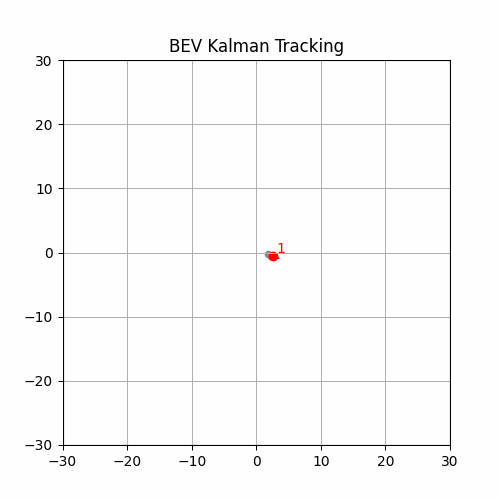

In [66]:
import imageio
from IPython.display import Image, display

imageio.mimsave(
    "/content/kalman_bev.gif",
    bev_frames,
    fps=5
)

display(Image(filename="/content/kalman_bev.gif"))

In [67]:
# =========================
# Save near-miss CSV log
# =========================
import pandas as pd
log_csv = os.path.join(EVENT_DIR, "near_miss_log.csv")
pd.DataFrame(event_log_rows).to_csv(log_csv, index=False)
print("Saved near-miss log:", log_csv)

# Show directory contents
print("\nEvent dir contents:")
!ls -lh "$EVENT_DIR" | head -n 50

Saved near-miss log: /content/near_miss_events/near_miss_log.csv

Event dir contents:
total 56M
-rw-r--r-- 1 root root  26M Jan 30 17:35 f0020_id05_ttc0.96_radar.gif
-rw-r--r-- 1 root root 2.9M Jan 30 17:34 f0020_id05_ttc0.96_radar.mp4
-rw-r--r-- 1 root root  26M Jan 30 17:35 f0021_id02_ttc0.34_radar.gif
-rw-r--r-- 1 root root 2.9M Jan 30 17:35 f0021_id02_ttc0.34_radar.mp4
-rw-r--r-- 1 root root  217 Jan 30 17:41 near_miss_log.csv
